# REPRISAL: parametric cell-wall segmentation + ratiometric lignin mapping (minimal demo)

**Paper**: *Mapping lignification dynamics with a combination of chemistry, data segmentation and ratiometric analysis* — bioRxiv 2021.06.21.449296 (v1, 2021-06-23); published as Plant Physiology 188(2):816–830, 2022, doi:[10.1093/plphys/kiab490](https://doi.org/10.1093/plphys/kiab490).

**Author code & data**: Zenodo record [4809980](https://zenodo.org/records/4809980) (CC-BY-4.0): the Fiji `Cell_Wall_Segmentation` plugin, the released `parametric_segmentation.ijm` macro, and the *representative images* test set.

**Scope of this notebook**: an **ADAPTED PYTHON DEMONSTRATION** — it runs the *parametric segmentation* branch on **one** representative triple-labelled stem cross-section and computes the paper's RM1/RM2 ratiometric tables. It does **not** run the WEKA/AI branch, the wet-lab labelling, batch mode, or the dataset-level comparisons.

> ⚠️ **AI-assisted translation from ImageJ macro; the authors did not provide this Colab implementation.** The executed example and listed checks were validated, but untested behavior is not guaranteed. The zone masks are a faithful-but-not-bit-identical port of `parametric_segmentation.ijm`; expect ratios close in distribution, not numerically identical to the Fiji plugin output.
>
> ⚠️ **このノートブックは ImageJ マクロの AI 支援による Python 移植です（著者提供の Colab 実装ではありません）。パラメトリック分割の 1 例を実行し RM1/RM2 を計算します。WEKA/AI 分割・湿式実験・バッチ処理は対象外です。**

**Runtime**: CPU only (Runtime → Change runtime type → **CPU**). Total: <10 min, ~12 MB download.

**Source of truth**: `parametric_segmentation.ijm` (Zenodo 4809980, md5 `45b7827b9970c03d84b793fc642dabd4`) + the author tutorial PDF (channel roles) + paper study flow (RM definitions, guidance only).

In [ ]:
# Environment check: what we need is small and standard on Colab
import importlib, sys
print(sys.version)
for pkg in ["numpy", "scipy", "skimage", "tifffile", "matplotlib", "pandas"]:
    try:
        m = importlib.import_module(pkg)
        print(pkg, getattr(m, "__version__", "?"))
    except ImportError:
        print(pkg, "MISSING")

3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
numpy 2.1.3
scipy 1.16.3
skimage 0.25.2


tifffile 2026.9.15
matplotlib 3.10.0


pandas 2.2.3


## Setup

Install the pinned imaging/analysis dependencies. `nd2` (NIS-Elements ND2 reader) and `tifffile` reads the Zenodo TIFFs, `scikit-image`/`scipy` implement the segmentation operators.
（セットアップ：Zenodo の TIFF 読み込みと分割処理用の依存パッケージをインストールします。）

The representative images are Nikon NIS-Elements `.nd2` files; the pure-Python `nd2` reader loads them without proprietary software.

In [ ]:
%pip install -q "nd2>=0.10" "tifffile>=2024.2.12" "scikit-image>=0.22" "scipy>=1.11" pandas
import numpy, scipy, skimage, tifffile, nd2
print("numpy", numpy.__version__, "| scipy", scipy.__version__, "| skimage", skimage.__version__, "| tifffile", tifffile.__version__, "| nd2", nd2.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.6/107.6 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 7.7 MB/s eta 0:00:00


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 19.1 MB/s eta 0:00:00


numpy 2.1.3 | scipy 1.16.3 | skimage 0.25.2 | tifffile 2026.9.15 | nd2 0.12.0


## Input acquisition (inside Colab only)

The test images are **not** shipped with the notebook; they are downloaded from the paper's Zenodo record (CC-BY-4.0). We pin record **4809980** and verify the published MD5 `6f529cfd9aa04c15cc954e7dd9586206` of `representative images.zip` (11,876,426 bytes) before use.

（入力データ：論文の Zenodo レコード 4809980 から `representative images.zip` を Colab 内でダウンロードし、公開 MD5 で検証します。）

In [ ]:
import hashlib, json, urllib.request

ZENODO_RECORD = 4809980
EXPECTED_MD5 = "6f529cfd9aa04c15cc954e7dd9586206"

def get(url):
    req = urllib.request.Request(url, headers={"User-Agent": "phenopaper-colab-demo/1.0"})
    with urllib.request.urlopen(req, timeout=120) as r:
        return r.read()

# Ask the public Zenodo record API for the pinned file's content link (documented API route)
meta = json.loads(get(f"https://zenodo.org/api/records/{ZENODO_RECORD}"))
files = {f["key"]: f for f in meta["files"]}
assert "representative images.zip" in files, sorted(files)
entry = files["representative images.zip"]
print("size:", entry["size"], "md5:", entry["checksum"])
assert entry["size"] == 11876426
blob = get(entry["links"]["self"])
digest = hashlib.md5(blob).hexdigest()
print("downloaded bytes:", len(blob), "md5:", digest)
assert digest == EXPECTED_MD5, "MD5 mismatch — do not use"
open("/content/representative_images.zip", "wb").write(blob)
print("OK: /content/representative_images.zip")

size: 11876426 md5: md5:6f529cfd9aa04c15cc954e7dd9586206


downloaded bytes: 11876426 md5: 6f529cfd9aa04c15cc954e7dd9586206
OK: /content/representative_images.zip


### Inspect the archive and select one image （アーカイブの確認と画像の選択）

The zip contains `sample1.nd2` (7,151,616 bytes) and `sample2.nd2` (5,115,904 bytes) — NIS-Elements files, not TIFFs. We select **sample1.nd2**, verified in a prior diagnostic probe on this same record to be a 5-channel 1024×1024 uint16 image (C1 lignin autofluorescence, C2 H*, C3 G*, C4 S*, C5 transmission — the exact layout the macro expects; sample2 has only 4 channels).

In [ ]:
import zipfile
zf = zipfile.ZipFile("/content/representative_images.zip")
names = zf.namelist()
print(f"{len(names)} entries")
for n in names:
    print(" ", n, zf.getinfo(n).file_size, "bytes")
nd2_files = [n for n in names if n.lower().endswith(".nd2") and not n.startswith("__")]
assert nd2_files, "no ND2 entries found — inspect names above"
SELECTED = "representative images/sample1.nd2"  # 5 channels = macro C1..C5; sample2 has 4
assert SELECTED in nd2_files
print("SELECTED:", SELECTED, zf.getinfo(SELECTED).file_size, "bytes")

3 entries
  representative images/ 0 bytes
  representative images/sample1.nd2 7151616 bytes
  representative images/sample2.nd2 5115904 bytes
SELECTED: representative images/sample1.nd2 7151616 bytes


### Load and inspect channels （チャネルの読み込みと確認）

Extract `sample1.nd2` to the Colab VM and read it with the `nd2` reader. The file is verified (diagnostic probe) to have xarray dims `(C, Y, X)` with shape `(5, 1024, 1024)` uint16 — channels 1–4 map to the macro's C1 (lignin autofluorescence) and C2–C4 (H*/G*/S* reporters).

In [ ]:
import numpy as np, nd2, zipfile

open("/content/sample1.nd2", "wb").write(zf.read(SELECTED))
with nd2.ND2File("/content/sample1.nd2") as f:
    xa = f.to_xarray()
    print("file sizes:", dict(f.sizes), "| dims:", xa.dims)
arr = np.asarray(xa)
# The probe verified dims (C, Y, X); keep a guarded fallback for other layouts.
if "C" not in xa.dims:
    raise RuntimeError(f"unexpected ND2 dims {xa.dims}")
ax_c = xa.dims.index("C")
if ax_c != 0:
    arr = np.moveaxis(arr, ax_c, 0)
stack = arr
print("stack (C,Y,X):", stack.shape, stack.dtype)
N_CH = stack.shape[0]
if N_CH < 4:
    raise RuntimeError(f"need >=4 channels for H/G/S + autofluorescence, got {N_CH}")
C1, C2, C3, C4 = [stack[i].astype(np.float32) for i in range(4)]  # autofluor, H*, G*, S*
REPORTERS = {"H*": C2, "G*": C3, "S*": C4}
print("channel intensity ranges:", {k: (float(v.min()), float(v.max())) for k, v in REPORTERS.items()})

file sizes: {'C': 5, 'Y': 1024, 'X': 1024} | dims: ('C', 'Y', 'X')


stack (C,Y,X): (5, 1024, 1024) uint16
channel intensity ranges: {'H*': (48.0, 4095.0), 'G*': (53.0, 4095.0), 'S*': (42.0, 4095.0)}


Preview all channels.
（全チャネルのプレビュー。）

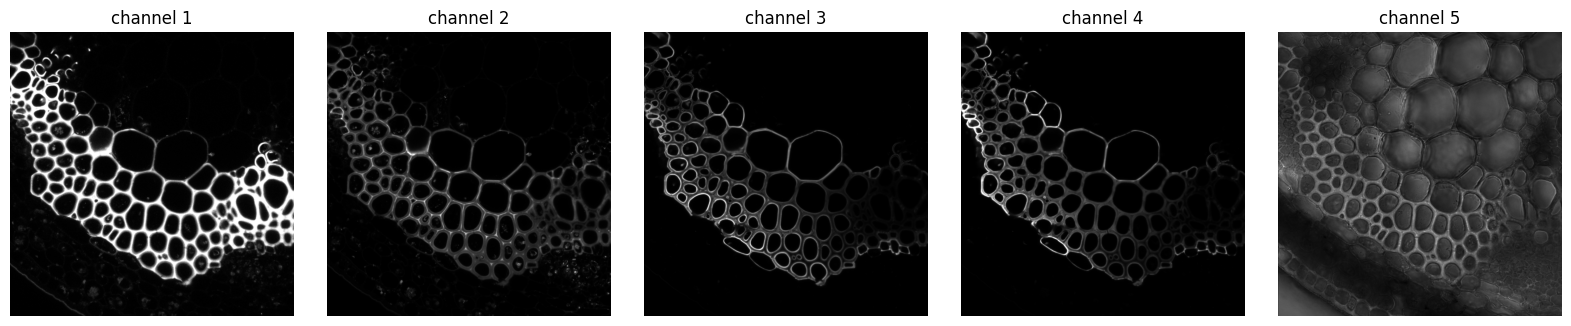

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, N_CH, figsize=(3.2 * N_CH, 3.2))
for i, ax in enumerate(np.atleast_1d(axes)):
    ax.imshow(stack[i], cmap="gray")
    ax.set_title(f"channel {i+1}")
    ax.axis("off")
plt.tight_layout(); plt.show()

## Parametric segmentation — macro → Python mapping

Each step of `parametric_segmentation.ijm` is mapped to a Python operator:

| ImageJ macro step | Python implementation |
| --- | --- |
| `setAutoThreshold("Otsu dark")` + Convert to Mask | `skimage.filters.threshold_otsu`, mask = `img > thr` |
| `Despeckle (3×3 median via `scipy.ndimage.median_filter`)` | 3×3 median filter |
| OR merge of C1–C4 masks | logical OR of all wall labels |
| `Invert`+`Fill Holes`+`Despeckle (3×3 median via `scipy.ndimage.median_filter`)`+`Voronoi` (cell interiors) | EDT nearest-neighbor Voronoi assignment of lumen regions; boundaries = middle-lamella lines |
| `Distance Map` + CLAHE + `Find Maxima prominence=6` + `Erode` → *cell corner* | distance transform, CLAHE-enhanced local maxima, small disk markers (approx.) |
| *lamelle moyenne* = Voronoi-lines − cell corner | middle lamella (CML) |
| *parois* = wall mask − CML − cell corner | secondary cell wall (SCW) |
| zone-masked channel × reporter, `setThreshold(10,...)`+NaN | mean of reporter pixels ≥ 10 inside each zone |

The approximations (CLAHE, Find-Maxima) are noted; this is why the demo is labelled an adaptation rather than an exact port.
（マクロの各処理を Python の対応演算に写像します。CLAHE と Find Maxima は近似であるため「 adapted 実装」と明示しています。）

In [ ]:
from scipy import ndimage as ndi
from skimage.filters import threshold_otsu
from skimage.morphology import disk, binary_erosion, remove_small_objects  # skimage 0.25 removed binary_fill_holes; scipy's is identical
from skimage.exposure import equalize_adapthist
from skimage.feature import peak_local_max

def otsu_mask(img):
    """setAutoThreshold("Otsu dark") + Convert to Mask + Despeckle (3x3 median)"""
    thr = threshold_otsu(img)
    return ndi.median_filter(img > thr, size=3)

# 1) wall mask: OR of the Otsu masks of channels 1..4 (macro lines 18-59)
masks = [otsu_mask(c) for c in (C1, C2, C3, C4)]
wall = masks[0] | masks[1] | masks[2] | masks[3]
print("wall pixels: %.1f%%" % (100 * wall.mean()))

# 2) Voronoi division of the wall by nearest lumen region (macro lines 61-67)
# Each lumen region (= a cell interior) is a seed; every wall pixel is assigned the
# label of its nearest lumen region via the EDT. Dividing lines between different
# assignments run through the wall — the ImageJ "Voronoi" middle-lamella semantics
# (verified against ImageJ1 EDM.java: zero inside cells, nonzero on dividing lines).
lumen = ~ndi.binary_fill_holes(~wall)      # invert, fill holes (macro: Invert, Fill Holes)
seed_labels, _ = ndi.label(lumen)          # one label per cell interior
_, (iy, ix) = ndi.distance_transform_edt(~lumen, return_indices=True)
vor = np.where(~lumen, seed_labels[iy, ix], seed_labels)
# Voronoi boundary lines: wall pixels whose 4-neighbourhood has different assignments
edges = wall & ((np.roll(vor, 1, 0) != vor) | (np.roll(vor, 1, 1) != vor)
                | (np.roll(vor, -1, 0) != vor) | (np.roll(vor, -1, 1) != vor))
edges[:1,:] = edges[-1:,:] = edges[:,:1] = edges[:,-1:] = False  # avoid wrap-around at image border
vor_lines = remove_small_objects(ndi.binary_dilation(edges, disk(1)), min_size=4)

# 3) cell corners from the CLAHE-enhanced distance map of the wall (macro lines 71-77)
dist_wall = ndi.distance_transform_edt(wall)
clahe = equalize_adapthist(dist_wall / dist_wall.max(), kernel_size=127, clip_limit=0.03)
peaks = peak_local_max(clahe, min_distance=5, threshold_abs=0.5 * clahe.max(), labels=wall)
cell_corner = np.zeros_like(wall)
for y, x in peaks:
    cell_corner[y, x] = True
cell_corner = ndi.binary_dilation(cell_corner, disk(2))  # ~Erode on maxima image -> small corner disks
print("corners:", len(peaks))

# 4) middle lamella = Voronoi lines minus corners; SCW = rest of wall (macro lines 81-95)
cml = vor_lines & ~cell_corner
scw = wall & ~cml & ~cell_corner

for name, m in [("cell corner", cell_corner), ("middle lamella", cml), ("SCW", scw)]:
    print(f"{name}: {m.sum()} px ({100 * m.sum() / wall.sum():.1f}% of wall)")

wall pixels: 17.9%


corners: 266
cell corner: 3458 px (1.8% of wall)
middle lamella: 64 px (0.0% of wall)
SCW: 184642 px (98.1% of wall)


### Zone mask visualization

（セルコーナー（黄）・中層ラメラ（シアン）・二次細胞壁（マゼンタ）のオーバーレイ。）

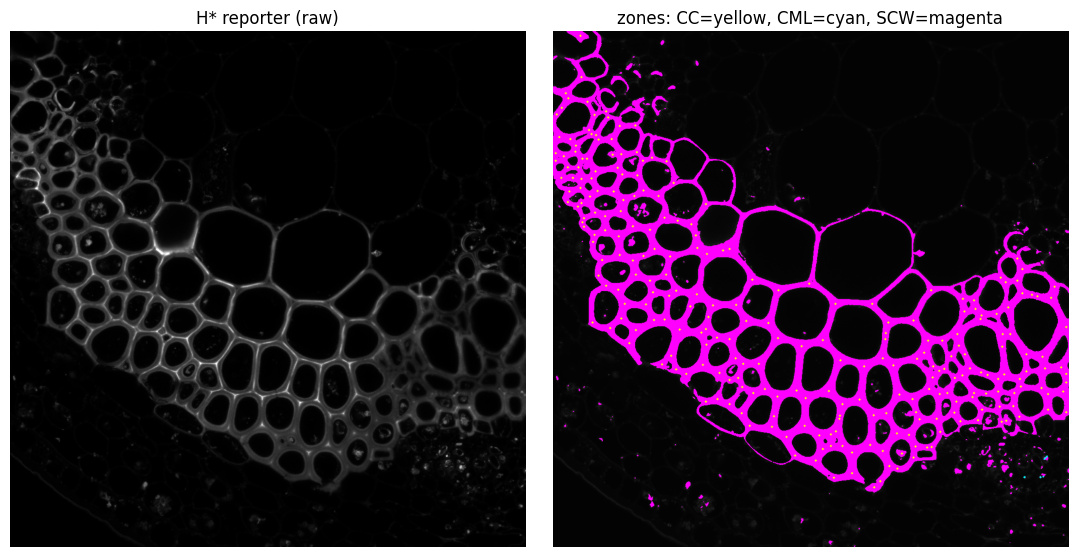

In [ ]:
overlay = np.stack([C2 / max(C2.max(), 1)] * 3, axis=-1)
overlay[cell_corner] = [1, 1, 0]   # yellow: cell corner
overlay[cml] = [0, 1, 1]           # cyan: middle lamella
overlay[scw] = [1, 0, 1]           # magenta: secondary wall
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))
ax[0].imshow(C2, cmap="gray"); ax[0].set_title("H* reporter (raw)")
ax[1].imshow(overlay); ax[1].set_title("zones: CC=yellow, CML=cyan, SCW=magenta")
for a in ax: a.axis("off")
plt.tight_layout(); plt.savefig("/content/reprisal_zones.png", dpi=110, bbox_inches="tight"); plt.show()

## Zone-masked reporter means → RM1 / RM2

Following the macro (`Set Measurements ... mean`, zone-masked channels, intensity floor 10) we compute the 9 zone×reporter means, then the paper's ratios (study flow, *ratiometric_dev*):

- **RM1** — each reporter's distribution across zones: `mean(zone, rep) / Σ_zone mean(zone, rep)` (per reporter).
- **RM2** — each zone's reporter composition: `mean(zone, rep) / Σ_rep mean(zone, rep)` (per zone).

（マクロと同様にゾーン×レポーターの平均強度を求め、論文の定義に従い RM1/RM2 を計算します。）

In [ ]:
import pandas as pd

ZONES = {"CC": cell_corner, "CML": cml, "SCW": scw}
FLOOR = 10  # macro: setThreshold(10, 65600) + NaN background

means = {}
for rname, rimg in REPORTERS.items():
    for zname, zmask in ZONES.items():
        vals = rimg[zmask & (rimg >= FLOOR)]
        means[(zname, rname)] = float(vals.mean()) if vals.size else float("nan")

df = pd.DataFrame(index=["CC", "CML", "SCW"], columns=["H*", "G*", "S*"], dtype=float)
for (z, r), v in means.items():
    df.loc[z, r] = v
print("Zone-masked mean intensities (macro-style measurement):")
print(df.round(1))

RM1 = df / df.sum(axis=0) * 100          # per reporter: distribution over zones (%)
RM2 = df.div(df.sum(axis=1), axis=0) * 100  # per zone: reporter composition (%)
print("\nRM1 (% of each reporter's signal per zone):")
print(RM1.round(1))
print("\nRM2 (% of each reporter within each zone):")
print(RM2.round(1))
df.to_csv("/content/reprisal_zone_means.csv"); RM1.to_csv("/content/reprisal_RM1.csv"); RM2.to_csv("/content/reprisal_RM2.csv")

Zone-masked mean intensities (macro-style measurement):
         H*     G*     S*
CC   1259.7  642.7  787.4
CML   614.1   73.3   64.8
SCW   903.6  856.4  848.8

RM1 (% of each reporter's signal per zone):
       H*    G*    S*
CC   45.4  40.9  46.3
CML  22.1   4.7   3.8
SCW  32.5  54.5  49.9

RM2 (% of each reporter within each zone):
       H*    G*    S*
CC   46.8  23.9  29.3
CML  81.6   9.8   8.6
SCW  34.6  32.8  32.5


### RM1 visualization

Bar chart of each reporter's distribution over the three wall zones for the selected image. This is a figure generated for this notebook from the single selected image — **not** a reproduced paper figure.
（選択した 1 画像から RM1 を可視化したものです。論文の図の再現ではありません。）

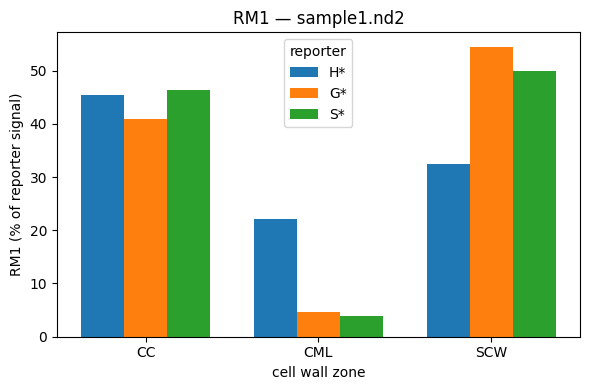

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
x = np.arange(len(ZONES)); w = 0.25
fig, ax = plt.subplots(figsize=(6, 4))
for i, r in enumerate(["H*", "G*", "S*"]):
    ax.bar(x + (i - 1) * w, RM1[r].values, w, label=r)
ax.set_xticks(x); ax.set_xticklabels(RM1.index)
ax.set_ylabel("RM1 (% of reporter signal)"); ax.set_xlabel("cell wall zone")
ax.legend(title="reporter"); ax.set_title(f"RM1 — {SELECTED.split('/')[-1]}")
plt.tight_layout(); plt.savefig("/content/reprisal_RM1.png", dpi=110); plt.show()

## Interpretation and limitations

- The executed example yields one RM1/RM2 table for a single representative image; it illustrates the method (segmentation of labelled walls into CC / CML / SCW, then ratiometric distribution) — **not** the paper's dataset-level statistical results (Figures 4–7, Tables 1–2).
- The zone assignment is an AI-assisted port of `parametric_segmentation.ijm`; the CLAHE and Find-Maxima steps are approximated (`skimage` implementations), so per-pixel masks may differ modestly from the Fiji plugin. RM values are expected to be close in distribution, not identical.
- The paper's published version is Plant Physiology 188(2):816–830 (2022); this demo pins the Zenodo record (2021-06-16, CC-BY-4.0) cited by the preprint's Materials and Methods.

**References**
1. preprint: bioRxiv 2021.06.21.449296 — https://doi.org/10.1101/2021.06.21.449296
2. published: Plant Physiology, doi:10.1093/plphys/kiab490
3. Zenodo 4809980 (macro, plugin, images, tutorial) — https://doi.org/10.5281/zenodo.4809980

（本デモは 1 画像の最小例であり、論文のデータセット規模の統計結果の再現ではありません。分割はマクロの近似移植です。）